# Задание 3. Аномалии и отказы насосов

In [1]:
import sys, os
sys.path.insert(0, '/home/jovyan/work/etl')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from io_utils import read_table, write_mart, write_mart_to_pg, pg_engine

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score


## Загрузка

In [2]:
pump_sensors  = read_table('pump_sensors')
pump_failures = read_table('pump_failures')
pump_sensors['ts'] = pd.to_datetime(pump_sensors['ts'])
pump_failures['failure_ts'] = pd.to_datetime(pump_failures['failure_ts'])
print('sensors :', pump_sensors.shape)
print('failures:', pump_failures.shape)
pump_failures


sensors : (7200, 7)
failures: (5, 4)


,failure_id,pump_id,failure_ts,failure_type
0,1,1,2025-02-15 14:30:00,bearing
1,2,2,2025-02-22 09:10:00,overheat
2,3,3,2025-02-28 18:45:00,vibration
3,4,4,2025-02-10 03:20:00,electrical
4,5,5,2025-02-25 22:00:00,bearing


## z-score

In [3]:
df = pump_sensors.copy()
for col in ['vibration_mm_s', 'temperature_c', 'current_a']:
    grp = df.groupby('pump_id')[col]
    df[f'{col}_z'] = (df[col] - grp.transform('mean')) / grp.transform('std')

df['is_anomaly_z'] = (df[['vibration_mm_s_z', 'temperature_c_z', 'current_a_z']]
                      .abs() > 3).any(axis=1).astype(int)
print('Доля по z-score:', df['is_anomaly_z'].mean().round(4))


Доля по z-score: 0.0035


## Isolation Forest

In [4]:
iso = IsolationForest(contamination=0.02, random_state=42)
df['is_anomaly_iso'] = (iso.fit_predict(
    df[['vibration_mm_s', 'temperature_c', 'current_a', 'rpm']]
) == -1).astype(int)
print('Доля по IsolationForest:', df['is_anomaly_iso'].mean().round(4))


Доля по IsolationForest: 0.02


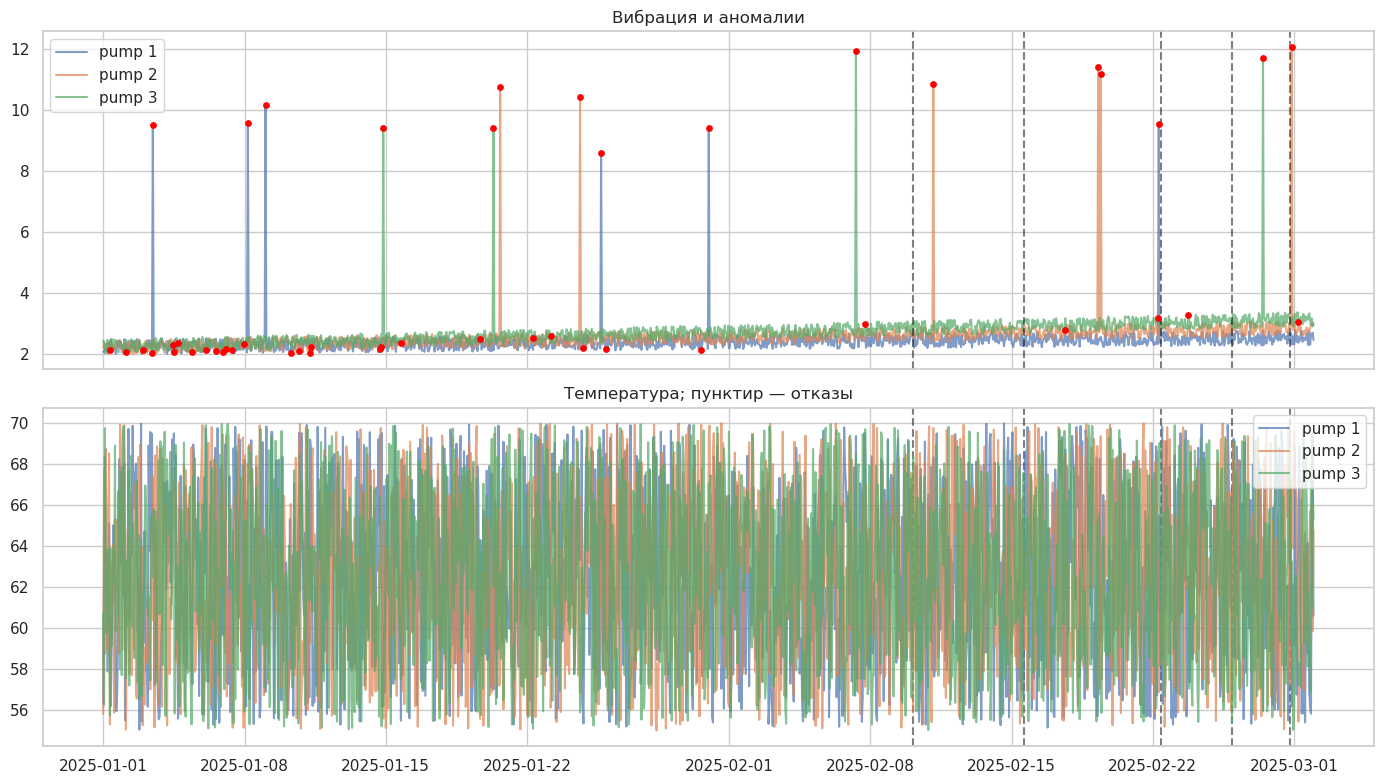

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for pid in sorted(df['pump_id'].unique())[:3]:
    sub = df[df['pump_id'] == pid].sort_values('ts')
    axes[0].plot(sub['ts'], sub['vibration_mm_s'], label=f'pump {pid}', alpha=0.7)
    anom = sub[sub['is_anomaly_iso'] == 1]
    axes[0].scatter(anom['ts'], anom['vibration_mm_s'], color='red', s=15, zorder=5)
axes[0].set_title('Вибрация и аномалии'); axes[0].legend()

for _, f in pump_failures.iterrows():
    axes[0].axvline(f['failure_ts'], color='black', linestyle='--', alpha=0.5)
    axes[1].axvline(f['failure_ts'], color='black', linestyle='--', alpha=0.5)

for pid in sorted(df['pump_id'].unique())[:3]:
    sub = df[df['pump_id'] == pid].sort_values('ts')
    axes[1].plot(sub['ts'], sub['temperature_c'], label=f'pump {pid}', alpha=0.7)
axes[1].set_title('Температура; пунктир — отказы'); axes[1].legend()
plt.tight_layout(); plt.show()


## Метка failure_soon

In [6]:
df['failure_soon'] = 0
for _, f in pump_failures.iterrows():
    mask = ((df['pump_id'] == f['pump_id'])
            & (df['ts'] >= f['failure_ts'] - pd.Timedelta(hours=24))
            & (df['ts'] < f['failure_ts']))
    df.loc[mask, 'failure_soon'] = 1
print('Положительный класс:', df['failure_soon'].sum(),
      f"({df['failure_soon'].mean():.3%})")


Положительный класс: 120 (1.667%)


## Сравнение признаков

In [7]:
agg = df.groupby('failure_soon')[['vibration_mm_s', 'temperature_c', 'current_a', 'rpm']].mean()
agg.index = ['обычно', 'перед отказом']
agg.round(2)


,vibration_mm_s,temperature_c,current_a,rpm
обычно,2.73,62.54,42.5,1475.08
перед отказом,3.00,62.69,42.6,1477.64


## Модель

In [8]:
feature_cols = ['vibration_mm_s', 'temperature_c', 'current_a', 'rpm',
                'vibration_mm_s_z', 'temperature_c_z', 'current_a_z']
X = df[feature_cols].fillna(0)
y = df['failure_soon']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
clf.fit(X_train, y_train)

proba_test = clf.predict_proba(X_test)[:, 1]
pred_test  = clf.predict(X_test)
print(classification_report(y_test, pred_test, digits=3))
print('ROC-AUC:', round(roc_auc_score(y_test, proba_test), 3))


              precision    recall  f1-score   support

           0      0.984     0.991     0.987      1770
           1      0.059     0.033     0.043        30

    accuracy                          0.975      1800
   macro avg      0.521     0.512     0.515      1800
weighted avg      0.968     0.975     0.972      1800

ROC-AUC: 0.748


## Risk score

In [9]:
df['risk_score'] = clf.predict_proba(df[feature_cols].fillna(0))[:, 1]

last_day = df['ts'].max() - pd.Timedelta(days=1)
risk_now = (df[df['ts'] >= last_day]
            .groupby('pump_id', as_index=False)
            .agg(avg_risk=('risk_score', 'mean'),
                 max_vibration=('vibration_mm_s', 'max')))
risk_now['avg_risk_pct'] = (risk_now['avg_risk'] * 100).round(1)
risk_now.sort_values('avg_risk', ascending=False)


,pump_id,avg_risk,max_vibration,avg_risk_pct
2,3,0.300249,3.381,30.0
3,4,0.269422,3.668,26.9
4,5,0.257440,3.957,25.7
1,2,0.201897,3.068,20.2
0,1,0.093880,2.790,9.4


## Сохранение

In [10]:
mart_failures = df[['ts', 'pump_id', 'vibration_mm_s', 'temperature_c',
                    'current_a', 'rpm',
                    'is_anomaly_z', 'is_anomaly_iso',
                    'failure_soon', 'risk_score']].copy()

write_mart(mart_failures.head(50000), 'mart_failures')
write_mart_to_pg(mart_failures, 'mart_failures')
write_mart_to_pg(risk_now, 'mart_pump_risk')
print('Saved')


Saved
